<a href="https://colab.research.google.com/github/7-atharva/AIML-Intern/blob/main/Practice_AIML_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Build Machine Learning models to predict machine failures using sensor data.**

### In this notebook i performed this given task:

 ✔ Data Loading

 ✔ Data Cleaning

 ✔ Data Visualization

 ✔ Feature Engineering

 ✔ Logistic Regression

 ✔ Random Forest

 ✔ Isolation Forest

 ✔ Pipeline

 ✔ Feature Importance

 ✔ Model Evaluation

**Step 1: Imported All the Required Libraries**

In [21]:
# Pandas is used to read and work with datasets in table format.
import pandas as pd

# NumPy is used for mathematical calculations and numerical operations.
# It helps to work efficiently with numbers and arrays.
import numpy as np

# Matplotlib is used to create basic graphs and charts.
import matplotlib.pyplot as plt

# Seaborn creates more attractive and informative statistical graphs.
import seaborn as sns

# This line tells matplotlib to display graphs inside Google Colab.
%matplotlib inline

# Ignore warning messages to keep the notebook output clean.
import warnings
warnings.filterwarnings("ignore")

Step 2 : Loading an Dataset

In [22]:
# Read the AI4I CSV file.
df = pd.read_csv("/Pragmatyc/ai4i2020.csv")

# Display the first 5 rows of the dataset.
# This helps us understand how the dataset looks.
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Step 3: Understanding the Dataset

In [25]:
# Display the total number of rows and columns.
# shape returns (rows, columns)
print("Dataset Shape :", df.shape)

Dataset Shape : (10000, 14)


Step 4: Displaying the Column Name

In [24]:
# This helps us understand what information is available.
print(df.columns)

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')


Step 5: Checking Data types, Missing Values and Duplicate rows

In [26]:
# Display detailed information about the dataset.
# It shows:
# - Column names
# - Data type
# - Number of non-null values
# - Memory usage
df.info()

# Count missing values in every column.
missing_values = df.isnull().sum()
print(missing_values)

# Count duplicate rows.
# Duplicate records can make the model biased.
print("Duplicate Records :", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

Step 6: STATISTICAL SUMMARY

**Generate statistical summary for numerical columns.**

It calculates:

Count

Mean

Standard Deviation

Minimum

Maximum

Percentiles

In [27]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Step 7: Removing Unnecessary Columns

In [28]:
from logging import error
# Droping an Unnecessary columns (UDI and Product Id is not useful for Machine analysis)
df.drop(columns=["UDI", "Product ID"], inplace=True, errors='ignore')

# Display remaining columns after removing unnecessary columns
print(df.columns)

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')


Step 8: Counting How many Machines Fail vs Not Fail

In [29]:
# Count how many machines failed and how many did not fail.
# This helps us understand whether the dataset is balanced or imbalanced.
print(df["Machine failure"].value_counts())

""" The Machine failure column contains only two values:
0 = Machine did NOT fail
1 = Machine failed
"""

Machine failure
0    9661
1     339
Name: count, dtype: int64


' The Machine failure column contains only two values:\n0 = Machine did NOT fail\n1 = Machine failed\n'

Step 9: Converting Categorial Data into Numerical Data


In [30]:
# Machine Type contains text values:
# L = Low
# M = Medium
# H = High

# Machine Learning models cannot understand text values directly.
# Therefore, we convert them into numerical columns using One-Hot Encoding.
# One-Hot Encoding is a technique used to convert categorical (text) data into numerical (0 and 1) values so that Machine Learning models can understand it.
# Example : 1 = Hot = Present
#           0 = Cold = Not Present
#           That is why it is called One-Hot Encoding.

df = pd.get_dummies(df, columns=["Type"], drop_first=True)
"""
 pd.get_dummies() : Converts categorical (text) values into numerical columns containing 0s and 1s.
# columns=["Type"] : Apply One-Hot Encoding only to the Type column.
# drop_first=True : Remove the first category (H) to avoid redundant information and improve model efficiency.
# After Ecoding Here : (1, 0) → L also Present in True(1) and False(0)
                       (0, 1) → M False(0), True(1)
                       (0, 0) → H False(0), False(0)
"""
# Display first 5 rows after encoding
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,True,False
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,True,False
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,True,False
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,True,False


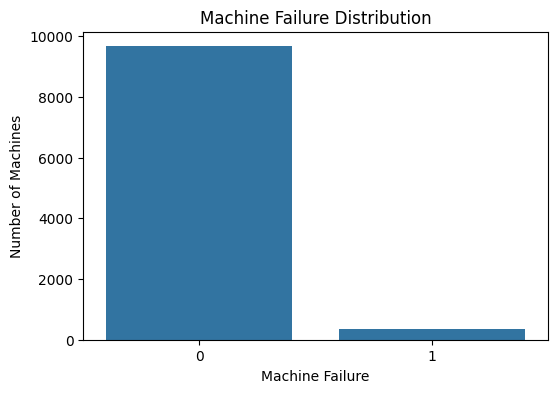

' This graph shows the number of normal machines and failed machines.\n    We can see that machine failures are much fewer than normal machines, which means the dataset is imbalanced\n    '

In [31]:
# Create a count plot for Machine Failure

plt.figure(figsize=(6,4))
sns.countplot(x="Machine failure", data=df)
plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Number of Machines")
plt.show()

""" This graph shows the number of normal machines and failed machines.
    We can see that machine failures are much fewer than normal machines, which means the dataset is imbalanced
    """

Step 10: HISTOGRAM OF NUMERICAL FEATURES

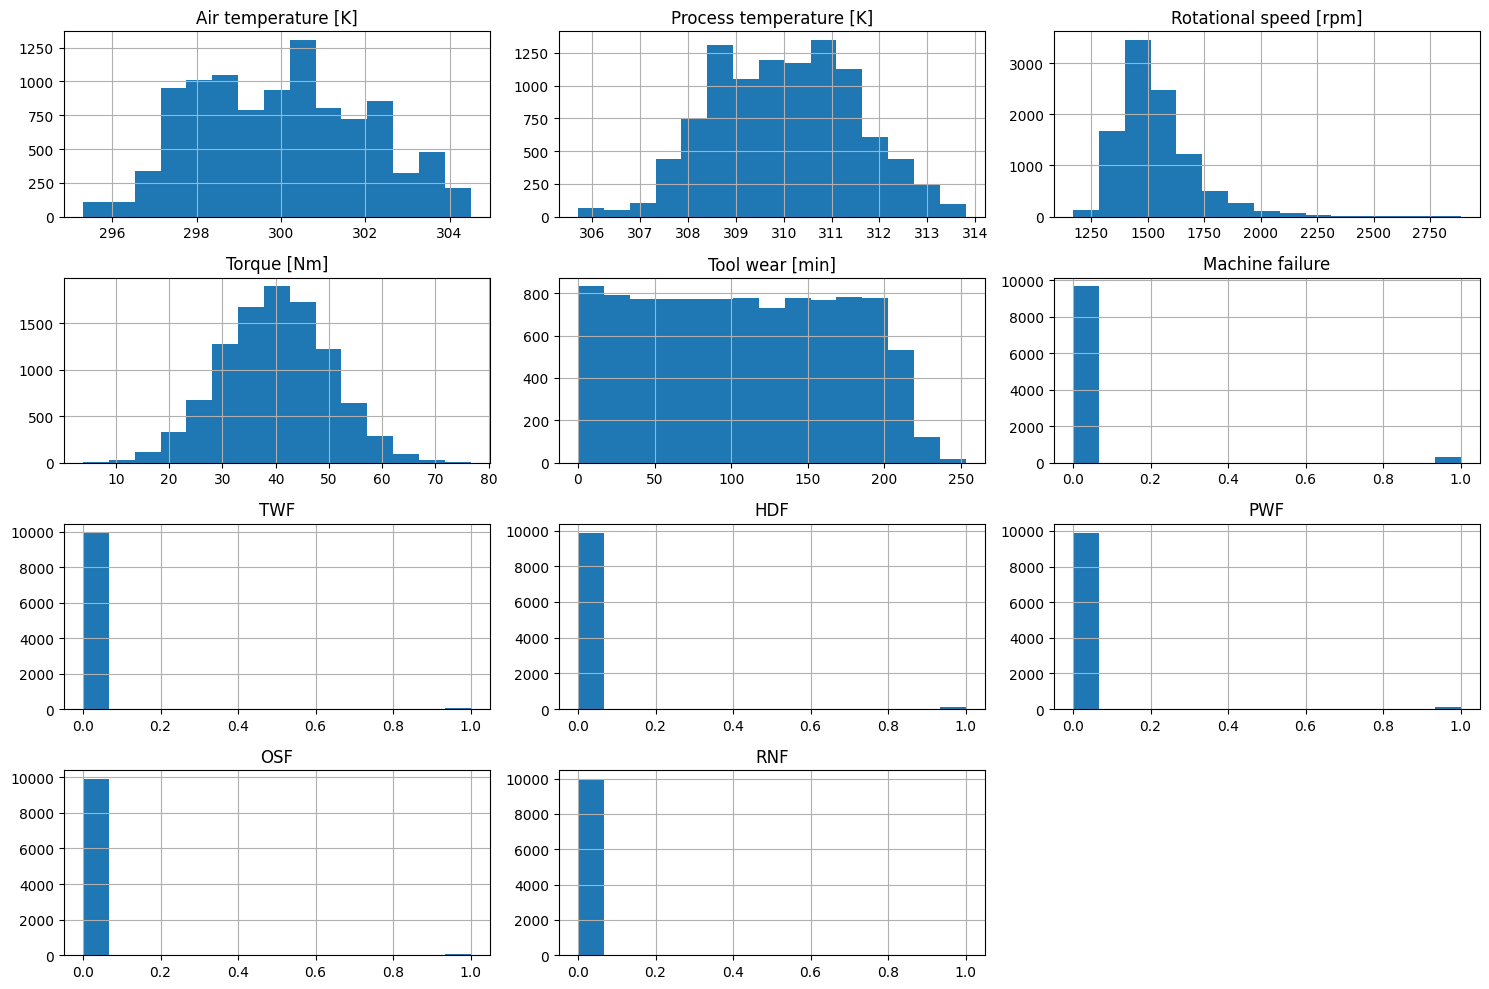

"\nFor Example : # Below graph shows the distribution of rotational speed. Most machines operate around 1500 rpm.\n The histogram of Rotational speed [rpm] shows how many machines in dataset operate at specific speeds.\n Such as :\n 1) The Peak: Most machines operate around 1500 RPM, which is the center of the distribution.\n 2) The Spread: Most data points are tightly packed between 1400 and 1700 RPM.\n 3) Outliers: There is a 'tail' on the right side, showing that a few machines run at much higher speeds (up to nearly 3000 RPM),\n              which could be instances of unusual operation or potential failure conditions.\n"

In [32]:
# Plot histograms for all numerical columns in the dataset.
# A histogram shows how the values of a feature are distributed.
df.hist(
    figsize=(15,10),   # Set the overall figure size to 15 inches wide and 10 inches tall.
    bins=15            # Divide the values into 20 groups (called bins).
)

# Automatically adjust the spacing between all histograms
# so that titles and labels do not overlap.
plt.tight_layout()

# Display all the histograms on the screen.
plt.show()

"""
For Example : # Below graph shows the distribution of rotational speed. Most machines operate around 1500 rpm.
 The histogram of Rotational speed [rpm] shows how many machines in dataset operate at specific speeds.
 Such as :
 1) The Peak: Most machines operate around 1500 RPM, which is the center of the distribution.
 2) The Spread: Most data points are tightly packed between 1400 and 1700 RPM.
 3) Outliers: There is a 'tail' on the right side, showing that a few machines run at much higher speeds (up to nearly 3000 RPM),
              which could be instances of unusual operation or potential failure conditions.
"""

Step 11 : BoxPlot for Outlier Detection

Boxplots help to identify outliers. Outliers are unusually high or low sensor values that may indicate abnormal machine behavior or possible faults.

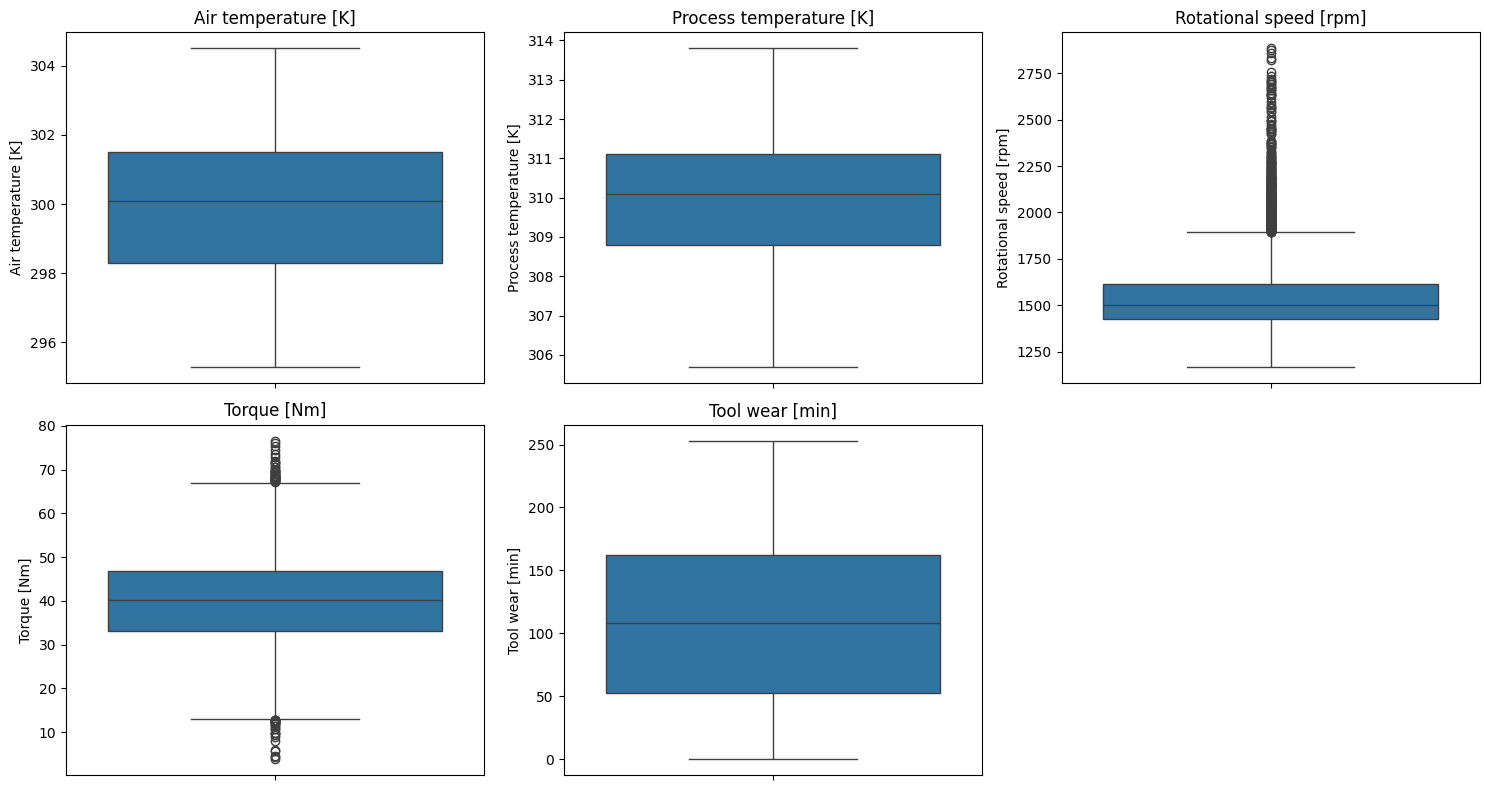

In [33]:
# Create boxplots for important sensor values.

plt.figure(figsize=(15,8))
columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]
for i, col in enumerate(columns, 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**For Example** the BoxPlot for Torque shows the distribution and spread of the data :

 * The Box: Represents the middle 50% of the data. The line inside the box is the Median (the middle value).

 * The Whiskers: These lines extending from the box show the typical range of the torque values.
* The Dots (Outliers): Those individual points on the far left and far right are outliers. These represent machines with unusually low or high torque compared to the rest, which might indicate abnormal operating conditions.

### **Step 12: Correlation Analysis**
The correlation heatmap shows how strongly different features are related. Positive values indicate that two variables increase together, while negative values indicate that one variable increases as the other decreases.

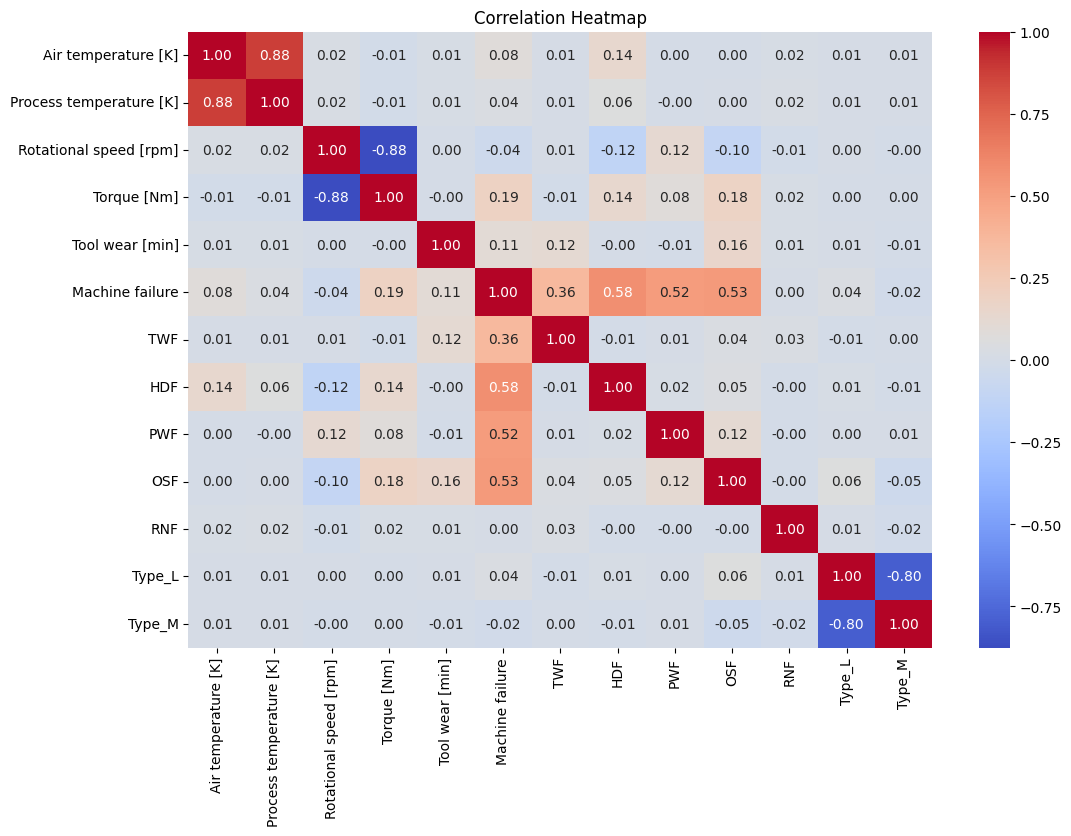

In [34]:
# Calculate the correlation between all numerical features.
# Correlation tells us how strongly two variables are related.
correlation = df.corr()

# Display the correlation matrix as a heatmap.
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

# Output
# Heatmap shows relationships between features using correlation values. Correlation shows how strongly two variables are related.
# Example: High torque may relate to machine failure.

# This Correlation Heatmap tells you how different features relate to each other:

# Red/Warm colors (near 1.0): Show a strong positive relationship (e.g., as Air Temperature goes up, Process Temperature also goes up).
# Blue/Cool colors (near -0.88): Show a strong inverse relationship (e.g., when Rotational Speed goes up, Torque usually goes down).
# Near 0: Means the two features don't have a clear linear relationship.


# The heatmap shows the correlation between all numeric features in dataset :

# Strong Positive Connection (Red): Notice the 0.88 between 'Air temperature' and 'Process temperature'. This means as the air gets hotter, the machine's internal process temperature almost always follows.
# Strong Negative Connection (Blue): Notice the -0.88 between 'Torque' and 'Rotational speed'. This means when the machine spins faster, the twisting force (torque) drops significantly.
# Machine Failure Indicators: Look at the 'Machine failure' row. Features like HDF, PWF, and OSF have higher numbers compared to others, suggesting these specific failure modes are the strongest indicators that a general machine failure is occurring.
# No Connection (White/Light): Values near 0.00 (like 'RNF' vs 'Torque') mean those two things have nothing to do with each other.

**Step 13 : Checking which features are more related to Machine Failure**

In [35]:
# Display the correlation of all features with Machine Failure.
# Sorting helps us quickly identify the most influential features.
failure_corr = correlation["Machine failure"].sort_values(ascending=False)

print(failure_corr)

# Machine Failure has a correlation of 1 with itself, which is expected.
# From the correlation analysis, we found that HDF, OSF, PWF, and TWF are the most influential features related to machine failure.
# Features like Torque and Tool Wear have a smaller positive impact, while Rotational Speed and Type_M show a very weak negative relationship.
# So, This analysis helped us to understand which features are most important before building the machine learning model.
# The key features are HDF, OSF, PWF, TWF, Torque, and Tool Wear because they have the highest positive correlation with Machine Failure.
#   and the remaining features have weak or very weak correlation, so their impact on prediction is comparatively lower.

Machine failure            1.000000
HDF                        0.575800
OSF                        0.531083
PWF                        0.522812
TWF                        0.362904
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
Type_L                     0.035643
RNF                        0.004516
Type_M                    -0.022432
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64


**Step 14: Machine Learning Model Building and Eluation**

In [36]:
# Defining the  INPUT FEATURES (X) and TARGET VARIABLE (y)

# The target variable is the column we want the model to predict.
# Here, our goal is to predict whether the machine will fail or not.
# "Machine failure" contains 0 (No Failure) and 1 (Failure).
y = df["Machine failure"]

# The input features are all the remaining columns.
# These sensor values will be used by the model to learn patterns and predict machine failure.
X = df.drop("Machine failure", axis=1)

# Display the number of rows and columns in the input features (X)
print("Shape of X (Features):", X.shape)

# Display the number of values in the target variable (y)
print("Shape of y (Target):", y.shape)

Shape of X (Features): (10000, 12)
Shape of y (Target): (10000,)


**Now Spliting the data into Training and Testing Set**

In [37]:
# Import train_test_split function to divide the dataset into training and testing data
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing data.
# 80% of the data is used for training.
# 20% is kept aside for testing the model on unseen data.
X_train, X_test, y_train, y_test = train_test_split(

    X,                 # Input features (independent variables)
    y,                 # Target variable (Machine Failure)

    test_size=0.20,    # Reserve 20% of the data for testing.
                       # The remaining 80% will be used for training.
    random_state=42,    # Set a fixed random value so that the data is split the same way every time.
# The random_state parameter is used to make the train-test split reproducible. By setting a fixed value such as 42, the dataset is split in the same way every time the code is executed. This ensures consistent and repeatable results. The value 42 itself is not mandatory; any integer like 1, 10, or 100 can be used. We commonly use 42 because it is the standard value used in many tutorials and examples.

    stratify=y         # Maintain the same proportion of each class
                       # (Machine Failure = 0 and 1) in both training and testing datasets.
)
# Display the size of each dataset
# Display the number of rows and columns in the training feature dataset.
print("Training Features :", X_train.shape)

# Display the number of rows and columns in the testing feature dataset.
print("Testing Features  :", X_test.shape)

# Display the number of target values in the training dataset.
print("Training Target   :", y_train.shape)

# Display the number of target values in the testing dataset.
print("Testing Target    :", y_test.shape)


Training Features : (8000, 12)
Testing Features  : (2000, 12)
Training Target   : (8000,)
Testing Target    : (2000,)


* 8000 records are used to train the model.
* 2000 records are used to test the model.
* 13 represents the number of input features.
* Training Target   : (8000,)
Testing Target    : (2000,) where (8000,) → 8000 and (2000,) → 2000  values in a one-dimensional Series (As Machine Failure is 0 or 1 we have just one column)

**Feature Scaling for Logistic Regression**



In [38]:
# Logistic Regression works better when numerical features are on a similar scale.
# StandardScaler converts all features to a common scale.

from sklearn.preprocessing import StandardScaler

# I used StandardScaler because Logistic Regression performs better when all numerical features have a similar range.
# Create the scaler
scaler = StandardScaler()

# StandardScaler transforms every feature so that:
# Mean (Average) = 0
# Standard Deviation = 1

# Formula used:
#                x - Mean
# z = -------------------------------
#        Standard Deviation

# where,
# x  = Original value
# Mean = Average value of that feature
# Standard Deviation = Spread of the feature values

# Learn scaling values from the training data and transform it.
# fit()     -> Calculates Mean and Standard Deviation.
# transform()-> Applies the StandardScaler formula.
# Both operations together are performed by fit_transform().
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to the test data
X_test_scaled = scaler.transform(X_test)

**Now Traning the Logistic Regression Model**

* Logistic Regression is a supervised machine learning algorithm.
* It is mainly used for binary classification problems,where the output has only two classes.

 * In our project:
   * 0 = Machine will NOT fail
   * 1 = Machine WILL fail
 * Logistic Regression learns the relationship between the input features
* *(temperature, torque, tool wear, etc.)* and the target variable
*(Machine Failure)*.

In [39]:
# Import Logistic Regression algorithm
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
log_model = LogisticRegression(random_state=42)

# Training the model using the scaled training data
# So, during training, the model studies the relationship between the input features (X_train_scaled) and the target values (y_train).

# Example:
# Input Features                 Output
# -----------------------------------------
# Temp=300, Torque=40            0
# Temp=305, Torque=75            1
# Temp=299, Torque=35            0

# The model learns these patterns so it can predict machine failure for new machines.
log_model.fit(X_train_scaled, y_train)

# Predict machine failure for the test data by using the trained model
log_predictions = log_model.predict(X_test_scaled)
# predict() returns only the final prediction:
# 0 = No Machine Failure
# 1 = Machine Failure

# Predict probabilities (needed later for ROC-AUC)
log_probabilities = log_model.predict_proba(X_test_scaled)[:, 1]
# Now predicting the probability of each class.
# predict_proba() returns two probabilities:

# Column 0 = Probability of Class 0 (No Failure)
# Column 1 = Probability of Class 1 (Failure)

# Example:
# [[0.98, 0.02]
#  [0.15, 0.85]
#  [0.70, 0.30]]

# Row 1:                              Row 2:
# 98% chance of No Failure          # 15% chance of No Failure
# 2% chance of Failure              # 85% chance of Failure

# [:,1] selects only the probability of Class 1
# (Machine Failure).

# Example Output: [0.02, 0.85, 0.30]

**Now Trainging the Model using Random Forest**
* Random Forest is a supervised machine learning algorithm. It is mainly used for both classification and regression problems.

* In this project, we use it for binary classification:
    * 0 = Machine will NOT fail
    * 1 = Machine WILL fail

* Random Forest works by creating many Decision Trees. where each tree makes its own prediction.
* The final prediction is based on the majority vote of all trees.

 Example:

 Tree 1 -> Failure (1)

 Tree 2 -> No Failure (0)

 Tree 3 -> Failure (1)

 Tree 4 -> Failure (1)

 Tree 5 -> No Failure (0)

 Majority Vote:

 Failure = 3 votes

 No Failure = 2 votes

* Final Prediction = Failure (1)

In [41]:
# Import Random Forest algorithm
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,     # Create 100 Decision Trees.
    # More trees usually improve accuracy, but also increase training time.

    random_state=42       # Fix the random process so that
    # the model gives the same result every time.
)
# Train the Random Forest model using fit() which allows every Decision Tree to learn Patterns from the training data
rf_model.fit(X_train, y_train)

# Predict machine failure
rf_predictions = rf_model.predict(X_test)

# Predict probabilities
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]
# Predict the probability of each class.

# predict_proba() returns two probabilities:
    # Column 0 = Probability of No Failure
    # Column 1 = Probability of Machine Failure
# Example:
# [[0.97,0.03]
#  [0.15,0.85]
#  [0.80,0.20]]

# [:,1] selects only the probability
# of Machine Failure (Class 1).

# These probabilities are later used to calculate ROC Curve and AUC Score.

**Now Importing Evaluation Metrics**

In [45]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

# CREATE A FUNCTION TO EVALUATE ANY CLASSIFICATION MODEL

def evaluate_model(model_name, y_true, y_pred, y_probability):

    print("="*70)
    print(model_name)
    print("="*70)

    # Calculate Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    # Accuracy: It Measures the overall percentage of correct predictions.

    # Formula: Accuracy = (Correct Predictions / Total Predictions)

    # Example:
    # Total Machines = 100
    # Correct Predictions = 95

    # Accuracy = 95/100 = 95%


    # Calculate Precision
    precision = precision_score(y_true, y_pred)
    # Precision: It teels us Out of all machines predicted as "Failure", how many actually failed?

    # Formula:  Precision = TP / (TP + FP)

    # Example:
    # Predicted Failure = 20
    # Actually Failed = 18

    # Precision = 18/20 = 90%


    # Calculate Recall
    recall = recall_score(y_true, y_pred)
    # Recall: It tells us Out of all actual failed machines,  how many did the model correctly identify?

    # Formula:  Recall = TP / (TP + FN)

    # Example:
    # Actual Failed Machines = 25
    # Correctly Predicted = 20

    # Recall = 20/25 = 80%


    # Calculate F1 Score
    f1 = f1_score(y_true, y_pred)
    # F1-Score:It Combines Precision and Recall into one score.
    # It is useful when the dataset is imbalanced.

    # Formula:
    #   F1 = 2 × (Precision × Recall)
    #        --------------------------
    #         (Precision + Recall)

    # Higher F1-score means better overall performance.


    # Calculate ROC-AUC Score
    roc_auc = roc_auc_score(y_true, y_probability)
    # ROC-AUC Score:It Measures how well the model separates the two classes (Failure and No Failure).

    # Score ranges from 0 to 1.
    # 1.0 = Perfect Model
    # 0.9 = Excellent
    # 0.8 = Good
    # 0.5 = Random Guess

    # Higher ROC-AUC means better classification performance.

    # Print all evaluation metrics
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")

    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix\n")
    print(cm)
    # Confusion Matrix:It Shows the number of correct and incorrect predictions.

    # It contains:
    # True Positive (TP)
    # True Negative (TN)
    # False Positive (FP)
    # False Negative (FN)

    # It helps us understand exactly
    # where the model is making mistakes.

In [46]:
# Evaluating LOGISTIC REGRESSION

evaluate_model(
    "Logistic Regression",
    y_test,
    log_predictions,
    log_probabilities
)

Logistic Regression
Accuracy  : 0.9990
Precision : 1.0000
Recall    : 0.9706
F1 Score  : 0.9851
ROC-AUC   : 0.9730

Confusion Matrix

[[1932    0]
 [   2   66]]


The Logistic Regression model performed very well on the testing dataset.
* It achieved an accuracy of 99.90%, indicating that almost all predictions were correct.
* The precision is 100%, meaning every machine predicted as failed was actually a failed machine.
* The recall is 97.06%, which means the model detected almost all actual failures, missing only two cases.
* The F1 Score of 98.51% shows an excellent balance between precision and recall, and the
* ROC-AUC score of 97.30% indicates strong classification performance.
                    
                     Predicted

                      No Fail      Fail

      Actual
      No Fail          1932         0

      Fail               2          66

* From the confusion matrix, the model correctly identified 1932 non-failure cases and 66 failure cases, with only 2 incorrect predictions, demonstrating that the model is highly reliable for predicting machine failure.

In [47]:
# Evaulating RANDOM FOREST
evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions,
    rf_probabilities
)

Random Forest
Accuracy  : 0.9990
Precision : 1.0000
Recall    : 0.9706
F1 Score  : 0.9851
ROC-AUC   : 0.9907

Confusion Matrix

[[1932    0]
 [   2   66]]


* Actually Both Logistic Regression and Random Forest achieved an accuracy of 99.90%, a precision of 100%, a recall of 97.06%, and an F1 Score of 98.51%. Their confusion matrices are also identical, meaning both models made the same final predictions on the test data.
* However, Random Forest achieved a higher ROC-AUC score of 99.07% compared to Logistic Regression's 97.30%. This indicates that Random Forest is better at separating machine failure and non-failure cases based on prediction probabilities.
* Therefore, Random Forest is considered the better-performing model for this dataset.

**Now Comparing the Both Models**

In [48]:
# Create a Pandas DataFrame to compare the performance of Logistic Regression and Random Forest.
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    # Calculate the Accuracy of both models
    "Accuracy": [
        accuracy_score(y_test, log_predictions),
        accuracy_score(y_test, rf_predictions)
    ],
    # Calculate the Precision of both models
    "Precision": [
        precision_score(y_test, log_predictions),
        precision_score(y_test, rf_predictions)
    ],
    # Calculate the Recall of both models
    "Recall": [
        recall_score(y_test, log_predictions),
        recall_score(y_test, rf_predictions)
    ],
    # Calculate the F1 Score of both models
    "F1 Score": [
        f1_score(y_test, log_predictions),
        f1_score(y_test, rf_predictions)
    ],
    # # Calculate the ROC-AUC score of both models
    "ROC-AUC": [
        roc_auc_score(y_test, log_probabilities),
        roc_auc_score(y_test, rf_probabilities)
    ]
})
# Display the comparison table
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.999,1.0,0.970588,0.985075,0.973024
1,Random Forest,0.999,1.0,0.970588,0.985075,0.990717


I compared both models using Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Both models performed almost identically with 99.9% accuracy, but Random Forest achieved a higher ROC-AUC score (99.07%), indicating better classification performance. Therefore, Random Forest was selected as the final model.

Step 15: Isolation Forest
* Isolation Forest is an anomaly detection algorithm that identifies abnormal data by isolating it from normal data.

In [ ]:
# Now We Are Doing an ANOMALY DETECTION USING ISOLATION FOREST

# Import Isolation Forest algorithm
from sklearn.ensemble import IsolationForest

# Create the Isolation Forest model.
# contamination=0.02 means we assume about 2% of the machines are abnormal.
# random_state=42 makes the results reproducible.
isolation_model = IsolationForest(
    contamination=0.02,
    # Isolation Forest needs an estimate of how many abnormal records exist because it is an unsupervised algorithm. It does not know which machines are normal or abnormal in advance.
    random_state=42
)

# Train the Isolation Forest model using only the feature columns.
# Since Isolation Forest is an Unsupervised Learning algorithm, it does NOT need the target variable (Machine Failure).
isolation_model.fit(X)

# Predict anomalies.
# Output:
#  1  = Normal Machine
# -1  = Anomaly (Abnormal Machine)
anomaly_predictions = isolation_model.predict(X)

# Store anomaly predictions in a new column.
df["Anomaly"] = anomaly_predictions

# Count normal and abnormal machines.
print(df["Anomaly"].value_counts())

Anomaly
 1    9800
-1     200
Name: count, dtype: int64


So in this step, I used the Isolation Forest algorithm for anomaly detection. Unlike Logistic Regression and Random Forest, Isolation Forest is an unsupervised learning algorithm, so it does not require the target variable. It learns only from the feature data and identifies unusual or abnormal machine behavior. I set contamination = 0.02, which means I assumed that around 2% of the machines could be abnormal. After training the model, it predicted each machine as either Normal (1) or Anomaly (-1). Finally, I stored these predictions in a new column called Anomaly and counted the number of normal and abnormal machines.

**Step 16: Now Visualizing the Anomalies**

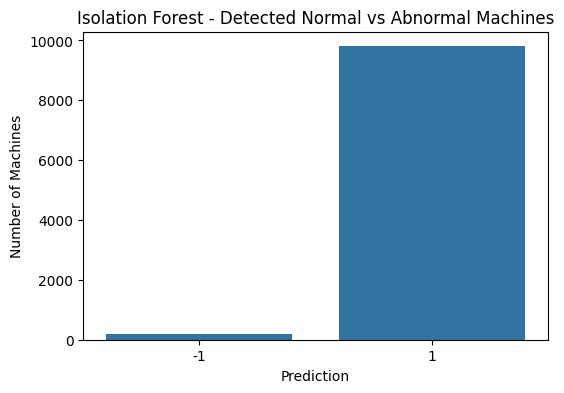

In [ ]:
# Create a graph showing how many normal and abnormal machines were detected.
plt.figure(figsize=(6,4))
# Create a count plot for the "Anomaly" column.
# It counts how many machines are:
#  1  = Normal Machine
# -1  = Abnormal (Anomaly) Machine
sns.countplot(x="Anomaly", data=df)

plt.title("Isolation Forest - Detected Normal vs Abnormal Machines")
plt.xlabel("Prediction")
plt.ylabel("Number of Machines")

plt.show()

This graph shows the results of the Isolation Forest algorithm. It displays the number of normal and abnormal machines detected in the dataset. Here, 1 represents normal machines, and -1 represents anomalous machines. The graph helps us quickly visualize the distribution of normal and abnormal machine behavior.

**Step 17: Now Building an Machine Learning Pipeline**

* A Pipeline is a Scikit-learn tool that combines multiple Machine Learning steps(Preprocessing and Model Training) into one workflow.

* Instead of writing separate code for each step, Pipeline executes them one after another automatically

In [ ]:
# Import the Pipeline class from Scikit-learn.
# A Pipeline combines multiple preprocessing and model steps into a single workflow.
from sklearn.pipeline import Pipeline

# Create a Pipeline which will performs the following steps automatically:
# Step 1 : StandardScaler scales the numerical features.
# Step 2 : Random Forest trains the machine learning model.
# The output of the first step automatically becomes the input to the second step.

pipeline = Pipeline([
    # First step: Scale the input features.
    ("scaler", StandardScaler()),
    # Second step: Train the Random Forest classifier.
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])
# Train the complete pipeline.
pipeline.fit(X_train, y_train)

# Predict using the pipeline.
pipeline_predictions = pipeline.predict(X_test)

# Display pipeline accuracy.
print("Pipeline Accuracy :",
      accuracy_score(y_test, pipeline_predictions))

Pipeline Accuracy : 0.999


Now in this step, I created a machine learning Pipeline. A Pipeline combines multiple preprocessing and model training steps into a single workflow. Here, the first step scales the input features using StandardScaler, and the second step trains the Random Forest classifier. When I call fit(), the pipeline automatically performs scaling and training. Similarly, when I call predict(), it automatically scales the test data and generates predictions. Finally, I calculated the pipeline accuracy to evaluate the complete workflow.

**Step 18: Feature Importance Using random Forest**
* Feature Importance is a technique used with Random Forest to identify which input features contribute the most to the model's predictions. Random Forest builds many decision trees, and whenever a feature helps split the data and improve prediction, its importance increases. After all trees are built, the model calculates an importance score for each feature.

In [49]:
# Get feature importance scores from the trained Random Forest model.
importance = rf_model.feature_importances_

# Create a DataFrame for better readability.
feature_importance = pd.DataFrame({
    # Feature names (Input columns)
    "Feature": X.columns,
    # Importance score assigned by Random Forest
    "Importance": importance
})
# Sort features from highest importance to lowest importance.
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
# Display feature importance table.
feature_importance

# Feature Importance tells us which sensor contributes the most while predicting machine failure.

,Feature,Importance
6,HDF,0.257003
8,OSF,0.217429
7,PWF,0.187350
5,TWF,0.113733
3,Torque [Nm],0.090007
2,Rotational speed [rpm],0.058782
4,Tool wear [min],0.032640
0,Air temperature [K],0.020156
1,Process temperature [K],0.017491
10,Type_L,0.002795


This table shows which features contribute the most to predicting machine failure. In our model, HDF, OSF, PWF, and TWF are the most important features, while RNF, Type_L, and Type_M have very little impact on the prediction. This analysis helps us understand which sensor values are most influential in the model's decision-making process

**Step 19: Visualizing Feature Importance**

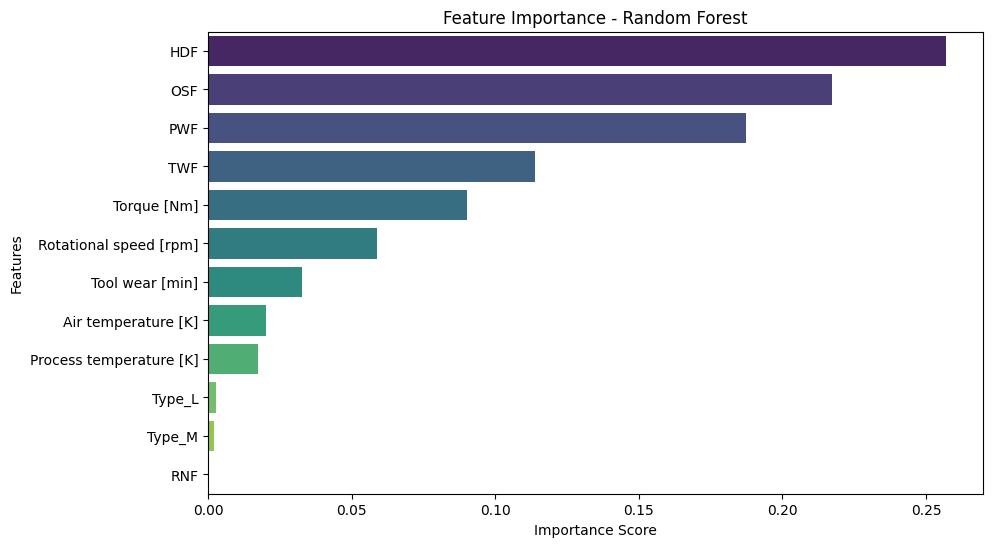

In [50]:
# Create a bar chart of feature importance.
plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance,
    palette="viridis"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

This graph represents the Feature Importance generated by the Random Forest model. It tells us which features contribute the most to predicting machine failure. In my results, Heat Dissipation Failure (HDF) is the most important feature, followed by Overstrain Failure (OSF) and Power Failure (PWF). Among the sensor readings, Torque has the highest importance, which means it has the greatest influence on predicting machine failures. On the other hand, Air Temperature, Process Temperature, Machine Type, and Random Failure have very little impact on the model. This helps us understand which machine parameters should be monitored more closely for effective predictive maintenance

**Now Displaying the Top 5 Most Imp Features**

In [ ]:
# Display only the top 5 important features.
print(feature_importance.head())

       Feature  Importance
6          HDF    0.258919
8          OSF    0.219757
7          PWF    0.193706
5          TWF    0.111718
3  Torque [Nm]    0.082561


**These features contribute the most to predicting machine failure because they represent the major operating conditions and failure mechanisms of the machine.**
1. HDF – Heat Dissipation Failure (Importance = 0.258919)
   * Means The machine cannot remove heat properly, causing overheating.
   * Why important? Overheating can damage machine components, so it is the most influential feature in predicting machine failure.
2. OSF – Overstrain Failure (Importance = 0.219757)
    * Means The machine is operating under excessive mechanical stress or load.
    * Why important? High strain increases the chance of machine breakdown, making it the second most important feature.
3. PWF – Power Failure (Importance = 0.193706)
    * Means: The machine experiences insufficient or interrupted power.
    * Why important? Power issues can stop the machine or cause abnormal operation, so it strongly affects failure prediction.
4. TWF – Tool Wear Failure (Importance = 0.111718)
    * Means: The machine tool has become worn out due to continuous use.
    * Why important? Excessive tool wear reduces machine performance and increases the risk of failure.
5. Torque [Nm] (Importance = 0.082561)
    * Menas: Torque is the rotational force produced by the machine.
    * Why important? Very high or very low torque indicates abnormal machine operation, making it an important indicator of machine failure.